# 4D - Alvos clusterizados e gate estatistico da hipotese

**Pergunta especifica.** Depois da distribuicao pixel-a-pixel do 4C, quais areas do Brasil respondem de modo parecido aos sinais do Pacifico, em que lag, com qual sentido seco/umido e com que estabilidade? A evidencia sustenta a hipotese: **El Nino favorece seca no Nordeste e chuva extrema/umida no Sul?**

**Metodologia.** Cada pixel vira um vetor com perfis `r(lag)` de todas as variaveis do master nas condicoes El Nino e La Nina. A clusterizacao por k-medias e usada apenas como sintese espacial descritiva; nao e modelo preditivo, nao e treino, nao e ML operacional. O gate final reavalia variavel por variavel no lag do alvo, com `N_eff`, estabilidade 1993-2009 vs 2010+ e classe de suporte da hipotese.

In [1]:
import sys; sys.path.insert(0,'.')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import xarray as xr
import fase4_utils as u

def zscore_np(a):
    mu = np.nanmean(a, axis=0)
    sd = np.nanstd(a, axis=0, ddof=1)
    sd[~np.isfinite(sd) | (sd == 0)] = 1.0
    return (a - mu) / sd

def kmeans_np(X, k, *, n_init=4, max_iter=60, seed=42, init_centers=None):
    rng = np.random.default_rng(seed)
    best_labels, best_centers, best_inertia = None, None, np.inf
    n = X.shape[0]
    starts = [init_centers] if init_centers is not None else [None] * n_init
    for start in starts:
        centers = start.copy() if start is not None else X[rng.choice(n, size=k, replace=False)].copy()
        labels = np.zeros(n, dtype=int)
        for _it in range(max_iter):
            d2 = ((X[:, None, :] - centers[None, :, :]) ** 2).sum(axis=2)
            new_labels = d2.argmin(axis=1)
            if np.array_equal(labels, new_labels):
                break
            labels = new_labels
            for j in range(k):
                m = labels == j
                if m.any():
                    centers[j] = X[m].mean(axis=0)
        inertia = float(((X - centers[labels]) ** 2).sum())
        if inertia < best_inertia:
            best_labels, best_centers, best_inertia = labels.copy(), centers.copy(), inertia
    return best_labels, best_centers, best_inertia

def silhouette_sample_np(X, labels, *, sample_size=1500, seed=42):
    rng = np.random.default_rng(seed)
    n = X.shape[0]
    idx = rng.choice(n, size=min(sample_size, n), replace=False)
    Xs = X[idx]; ls = labels[idx]
    d = np.sqrt(((Xs[:, None, :] - Xs[None, :, :]) ** 2).sum(axis=2))
    vals = []
    for i, lab in enumerate(ls):
        own = ls == lab
        if own.sum() <= 1:
            continue
        a = d[i, own].sum() / (own.sum() - 1)
        b = min(d[i, ls == other].mean() for other in np.unique(ls) if other != lab and np.any(ls == other))
        vals.append((b - a) / max(a, b))
    return float(np.mean(vals)) if vals else np.nan

ds = xr.open_zarr(u.ZSTATS/'phase4C_atlas_pixel.zarr')
px = pd.read_csv(u.FEAT/'phase4_chirps_pixels.csv')
best = pd.read_csv(u.STATS/'phase4C_best_lag_pixel.csv')
SUBLAGS = [int(l) for l in ds.lag.values if l <= 52 and l % 4 == 0]
vars_ok = [v for v in u.PACIFIC_VARS if v in ds.variavel.values]
blocks = []
for cond in ['el_nino','la_nina']:
    arr = ds[f'r_{cond}'].sel(variavel=vars_ok, lag=SUBLAGS).transpose('pixel','variavel','lag').values
    blocks.append(arr.reshape(arr.shape[0], -1))
feat = np.hstack(blocks)
ok = np.isfinite(feat).mean(axis=1) >= 0.95
X_full = np.nan_to_num(zscore_np(feat[ok]), nan=0.0, posinf=0.0, neginf=0.0)

# Escolha de K em amostra deterministica para manter 4D descritivo e executavel.
rng = np.random.default_rng(42)
sample_n = min(3000, X_full.shape[0])
sample_idx = rng.choice(X_full.shape[0], size=sample_n, replace=False)
Xs = X_full[sample_idx]
scores, fitted = {}, {}
for k in range(3, 8):
    lab_s, ctr_s, inertia_s = kmeans_np(Xs, k, n_init=4, max_iter=60, seed=42+k)
    scores[k] = silhouette_sample_np(Xs, lab_s, sample_size=1500, seed=420+k)
    fitted[k] = (lab_s, ctr_s, inertia_s)
K = max(scores, key=scores.get)
_, centers0, _ = fitted[K]
labels_ok, centers, inertia = kmeans_np(X_full, K, max_iter=20, seed=99, init_centers=centers0)
labels = np.full(len(px), -1); labels[ok] = labels_ok
print('silhueta por k na amostra:', {k: round(v,3) for k,v in scores.items()}, '| escolhido K =', K, '| amostra =', sample_n, '| variaveis no vetor:', len(vars_ok))
clusters = px.assign(cluster=labels)
u.save_table(clusters, 'phase4D_clusters_pixels.csv', index=False)

silhueta por k na amostra: {3: 0.156, 4: 0.161, 5: 0.148, 6: 0.137, 7: 0.154} | escolhido K = 4 | amostra = 3000 | variaveis no vetor: 31
[tabela] data\processed\parquet\statistics\phase4D_clusters_pixels.csv


WindowsPath('C:/DEV/NINO26/data/processed/parquet/statistics/phase4D_clusters_pixels.csv')

In [2]:
rows_rank, rows_lag = [], []
neb_mask = u.region_mask(px, u.REGIOES['NEB'])
sul_mask = u.region_mask(px, u.REGIOES['SUL'])
def regiao_predominante(m):
    n = max(int(m.sum()), 1)
    f_neb = float((m & neb_mask).sum() / n)
    f_sul = float((m & sul_mask).sum() / n)
    if f_neb >= f_sul and f_neb >= 0.35:
        return 'NEB', f_neb, f_sul
    if f_sul > f_neb and f_sul >= 0.35:
        return 'SUL', f_neb, f_sul
    return 'OUTROS', f_neb, f_sul

for c in range(K):
    m = clusters['cluster'].values == c
    regiao, frac_neb, frac_sul = regiao_predominante(m)
    cluster_best = best[best['pixel_id'].isin(px.loc[m, 'pixel_id'])]
    for cond in ['el_nino','la_nina']:
        cand_rows = []
        for v in vars_ok:
            sub = cluster_best[(cluster_best.condicao==cond) & (cluster_best.variavel==v)]
            bl = sub['best_lag_sem'].dropna(); rr = sub['r_no_best_lag'].dropna()
            if len(bl) == 0:
                continue
            cand_rows.append({'variavel': v, 'frac_sig': len(bl)/max(m.sum(),1), 'abs_r_med': abs(float(rr.median())),
                              'lag_med': float(bl.median()), 'lag_q25': float(bl.quantile(.25)), 'lag_q75': float(bl.quantile(.75)),
                              'r_med': float(rr.median())})
        if cand_rows:
            cand = pd.DataFrame(cand_rows)
            cand['score'] = cand['frac_sig'] * cand['abs_r_med']
            b = cand.sort_values('score', ascending=False).iloc[0]
            rows_lag.append({'cluster': c, 'regiao_predominante': regiao, 'frac_neb': round(frac_neb,3), 'frac_sul': round(frac_sul,3),
                'sinal': cond, 'variavel_dominante': b.variavel, 'nome_variavel_dominante': u.var_label(b.variavel, short=False),
                'n_pixels': int(m.sum()), 'frac_sig_%': round(100*b.frac_sig,1),
                'lag_mediano_sem': b.lag_med, 'lag_iqr_sem': f"{b.lag_q25:.0f}-{b.lag_q75:.0f}",
                'r_mediano': round(b.r_med,3), 'sentido': 'umido' if b.r_med>0 else 'seco',
                'score_afetacao': round(b.score,4)})
    en = cluster_best[cluster_best.condicao.eq('el_nino')]
    rows_rank.append({'cluster': c, 'regiao_predominante': regiao, 'frac_neb': round(frac_neb,3), 'frac_sul': round(frac_sul,3),
        'n_pixels': int(m.sum()),
        'abs_r_max_medio': round(float(en.groupby('pixel_id')['r_no_best_lag'].apply(lambda s: s.abs().max()).mean()),3) if len(en) else np.nan,
        'lat_media': round(float(px.loc[m,'lat'].mean()),1), 'lon_media': round(float(px.loc[m,'lon'].mean()),1)})
rank = pd.DataFrame(rows_rank).sort_values('abs_r_max_medio', ascending=False)
rank['alvo_prioritario'] = range(1, len(rank)+1)
u.save_table(rank, 'phase4D_cluster_ranking.csv', index=False)
lags_tab = pd.DataFrame(rows_lag)
u.save_table(lags_tab, 'phase4D_cluster_lags_por_sinal.csv', index=False)
print(rank.to_string(index=False)); print(); print(lags_tab.to_string(index=False))

[tabela] data\processed\parquet\statistics\phase4D_cluster_ranking.csv
[tabela] data\processed\parquet\statistics\phase4D_cluster_lags_por_sinal.csv
 cluster regiao_predominante  frac_neb  frac_sul  n_pixels  abs_r_max_medio  lat_media  lon_media  alvo_prioritario
       3                 NEB     0.366     0.000      2191            0.190      -16.3      -55.5                 1
       1              OUTROS     0.142     0.000      7879            0.178       -5.0      -59.0                 2
       0                 SUL     0.001     0.530      3001            0.154      -28.4      -57.4                 3
       2              OUTROS     0.126     0.006      6502            0.133      -14.5      -58.0                 4

 cluster regiao_predominante  frac_neb  frac_sul   sinal variavel_dominante              nome_variavel_dominante  n_pixels  frac_sig_%  lag_mediano_sem lag_iqr_sem  r_mediano sentido  score_afetacao
       0                 SUL     0.001     0.530 el_nino           ssr_

C:\Users\thiag\AppData\Local\Temp\ipykernel_28716\2526123671.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cores = cm.get_cmap('tab10', K)
C:\Users\thiag\AppData\Local\Temp\ipykernel_28716\2526123671.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  sc = u.pixel_map(ax, px, vals, cmap=cm.get_cmap('tab10', K), vmin=-.5, vmax=K-.5,


[figura] data\processed\figures\fase4\phase4D_mapa_clusters.png


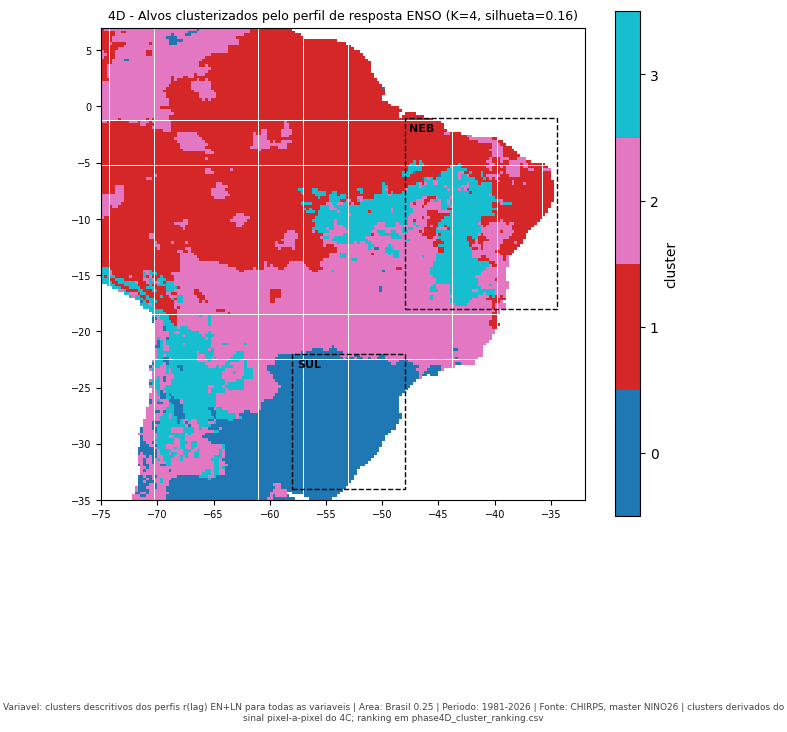

[figura] data\processed\figures\fase4\phase4D_perfis_clusters.png


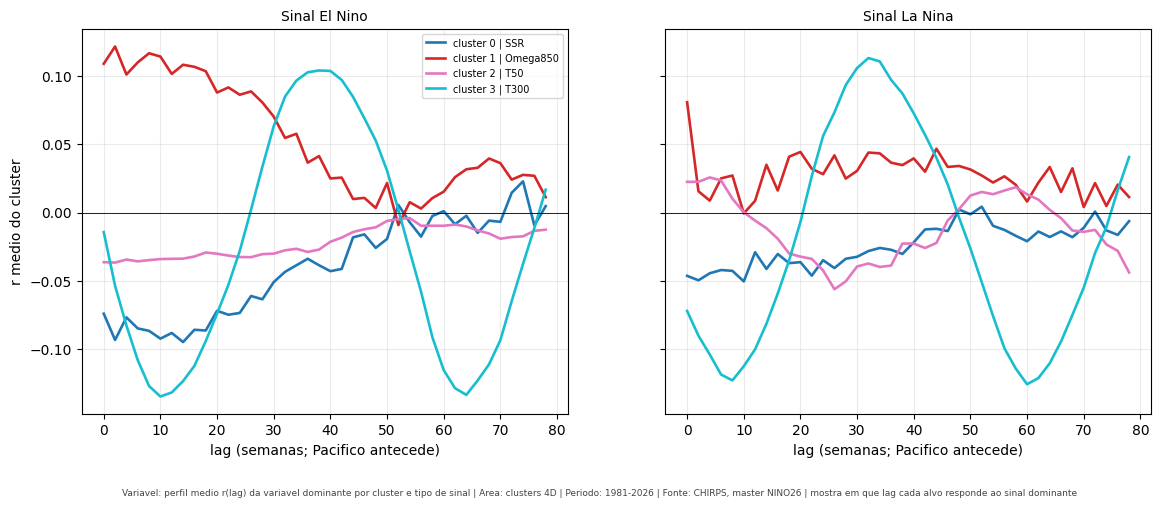

In [3]:
import matplotlib.cm as cm
cores = cm.get_cmap('tab10', K)
fig, ax = plt.subplots(figsize=(7.8, 8.2))
vals = np.where(clusters['cluster'].values>=0, clusters['cluster'].values, np.nan)
sc = u.pixel_map(ax, px, vals, cmap=cm.get_cmap('tab10', K), vmin=-.5, vmax=K-.5,
                 title=f'4D - Alvos clusterizados pelo perfil de resposta ENSO (K={K}, silhueta={scores[K]:.2f})')
cb = fig.colorbar(sc, ax=ax, ticks=range(K), shrink=.8); cb.set_label('cluster')
u.stamp_caption(fig, variavel='clusters descritivos dos perfis r(lag) EN+LN para todas as variaveis', area='Brasil 0.25', periodo='1981-2026', fonte='CHIRPS, master NINO26', extra='clusters derivados do sinal pixel-a-pixel do 4C; ranking em phase4D_cluster_ranking.csv')
u.save_fig(fig, 'phase4D_mapa_clusters.png')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13.8, 5), sharey=True)
for ax, cond, tit in [(axes[0],'r_el_nino','Sinal El Nino'), (axes[1],'r_la_nina','Sinal La Nina')]:
    sig_name = cond.replace('r_', '')
    for c in range(K):
        m = clusters['cluster'].values == c
        row = lags_tab[(lags_tab.cluster==c) & (lags_tab.sinal==sig_name)]
        if row.empty:
            continue
        vdom = row.iloc[0]['variavel_dominante']
        prof = np.nanmean(ds[cond].sel(variavel=vdom).values[:, m], axis=1)
        ax.plot(ds.lag.values, prof, color=cores(c), lw=1.9, label=f'cluster {c} | {u.var_label(vdom)}')
    ax.axhline(0, color='k', lw=.6); ax.set_xlabel('lag (semanas; Pacifico antecede)')
    ax.set_title(tit, fontsize=10); ax.grid(alpha=.25)
axes[0].set_ylabel('r medio do cluster'); axes[0].legend(fontsize=7, ncol=1)
u.stamp_caption(fig, variavel='perfil medio r(lag) da variavel dominante por cluster e tipo de sinal', area='clusters 4D', periodo='1981-2026', fonte='CHIRPS, master NINO26', extra='mostra em que lag cada alvo responde ao sinal dominante')
u.save_fig(fig, 'phase4D_perfis_clusters.png')
plt.show()

[tabela] data\processed\parquet\statistics\phase4D_estabilidade.csv
[tabela] data\processed\parquet\statistics\phase4D_gate_hipotese.csv
classe_hipotese
fora_da_hipotese        186
nao_suporta              39
contraria_hipotese       12
suporta_hipotese          9
suporta_com_ressalva      2


[figura] data\processed\figures\fase4\phase4D_sintese_gate.png


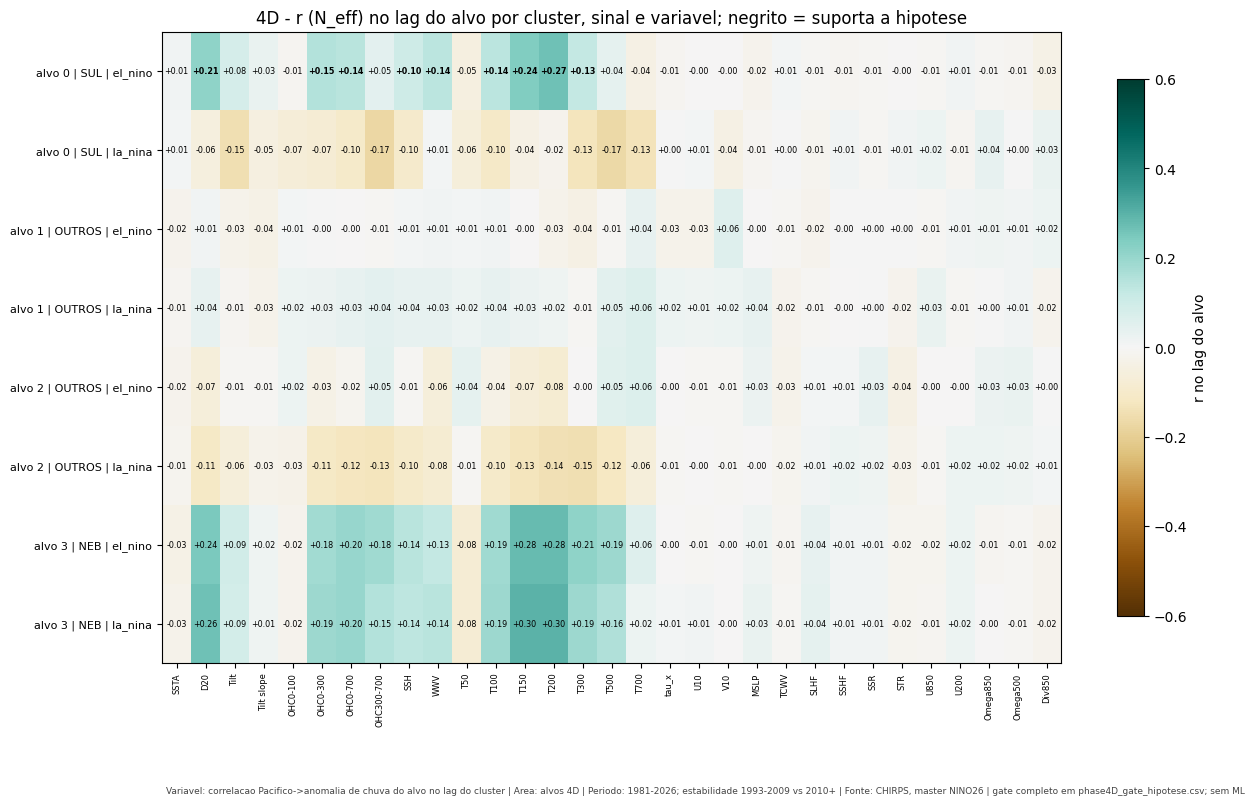

In [4]:
# Estabilidade por subperiodo e gate estatistico da hipotese NEB seco / Sul umido em El Nino.
Z, _px2 = u.build_chirps_weekly_zanom()
w = u.load_pacific_weekly()
idx = Z.index.intersection(w.index)
Z = Z.loc[idx]; w = w.reindex(idx)
alvo = pd.DataFrame({c: Z.iloc[:, np.where(clusters['cluster'].values==c)[0]].mean(axis=1) for c in range(K)})

def classe_hipotese(sinal, regiao, sentido, sig, estavel, lag):
    if sinal != 'el_nino' or regiao not in {'NEB', 'SUL'}:
        return 'fora_da_hipotese'
    esperado = 'seco' if regiao == 'NEB' else 'umido'
    if not sig:
        return 'nao_suporta'
    if sentido != esperado:
        return 'contraria_hipotese'
    if lag <= 6:
        return 'diagnostico_curto'
    if estavel:
        return 'suporta_hipotese'
    return 'suporta_com_ressalva'

rows = []
for c in range(K):
    for _, lrow in lags_tab[lags_tab.cluster==c].iterrows():
        L = lrow['lag_mediano_sem']
        if not np.isfinite(L):
            continue
        L = int(L); y = alvo[c]
        for v in vars_ok:
            x = w[v].shift(L).reindex(y.index)
            r0, p0, ne = u.neff_corr(x, y)
            r1, p1, _ = u.neff_corr(x.loc['1993':'2009'], y.loc['1993':'2009'])
            r2, p2, _ = u.neff_corr(x.loc['2010':], y.loc['2010':])
            sig = bool(np.isfinite(p0) and p0 < .1)
            estavel = bool(np.isfinite(p1) and np.isfinite(p2) and p1 < .1 and p2 < .1 and np.sign(r1) == np.sign(r2))
            sentido_var = 'umido' if np.isfinite(r0) and r0 > 0 else ('seco' if np.isfinite(r0) and r0 < 0 else '')
            classe = classe_hipotese(lrow['sinal'], lrow['regiao_predominante'], sentido_var, sig, estavel, L)
            rows.append({'cluster': c, 'regiao_predominante': lrow['regiao_predominante'], 'sinal': lrow['sinal'],
                'variavel': v, 'nome_variavel': u.var_label(v, short=False), 'grupo': u.var_group(v),
                'variavel_dominante_do_alvo': lrow['variavel_dominante'], 'lag_sem': L,
                'sentido_chuva': sentido_var,
                'r_total': round(r0,3) if np.isfinite(r0) else np.nan, 'p_total': round(p0,4) if np.isfinite(p0) else np.nan,
                'n_eff_total': round(ne,1) if np.isfinite(ne) else np.nan,
                'r_1993_2009': round(r1,3) if np.isfinite(r1) else np.nan, 'r_2010_hoje': round(r2,3) if np.isfinite(r2) else np.nan,
                'p_1993_2009': round(p1,4) if np.isfinite(p1) else np.nan, 'p_2010_hoje': round(p2,4) if np.isfinite(p2) else np.nan,
                'estavel': estavel, 'classe_hipotese': classe})
gate = pd.DataFrame(rows)
u.save_table(gate[['cluster','regiao_predominante','sinal','sentido_chuva','variavel','lag_sem','r_1993_2009','p_1993_2009','r_2010_hoje','p_2010_hoje','estavel']], 'phase4D_estabilidade.csv', index=False)
u.save_table(gate, 'phase4D_gate_hipotese.csv', index=False)
print(gate['classe_hipotese'].value_counts().to_string())

pv = gate.pivot_table(index=['cluster','regiao_predominante','sinal'], columns='variavel', values='r_total')
pv = pv[[v for v in vars_ok if v in pv.columns]]
fig, ax = plt.subplots(figsize=(14.5, .55*len(pv)+3.8))
im = ax.imshow(pv.values, cmap='BrBG', vmin=-.6, vmax=.6, aspect='auto')
ax.set_xticks(range(pv.shape[1])); ax.set_xticklabels([u.var_label(v) for v in pv.columns], fontsize=6, rotation=90)
ax.set_yticks(range(len(pv))); ax.set_yticklabels([f"alvo {c} | {r} | {s}" for c, r, s in pv.index], fontsize=8)
sub = gate.set_index(['cluster','regiao_predominante','sinal','variavel'])
for i, (c, rgn, s) in enumerate(pv.index):
    for j, v in enumerate(pv.columns):
        try:
            g = sub.loc[(c, rgn, s, v)]
            if np.isfinite(g['r_total']):
                ax.text(j, i, f"{g['r_total']:+.2f}", ha='center', va='center', fontsize=5.8,
                        weight='bold' if g['classe_hipotese']=='suporta_hipotese' else 'normal')
        except Exception:
            pass
ax.set_title('4D - r (N_eff) no lag do alvo por cluster, sinal e variavel; negrito = suporta a hipotese')
fig.colorbar(im, ax=ax, shrink=.85, label='r no lag do alvo')
u.stamp_caption(fig, variavel='correlacao Pacifico->anomalia de chuva do alvo no lag do cluster', area='alvos 4D', periodo='1981-2026; estabilidade 1993-2009 vs 2010+', fonte='CHIRPS, master NINO26', extra='gate completo em phase4D_gate_hipotese.csv; sem ML')
u.save_fig(fig, 'phase4D_sintese_gate.png')
plt.show()

**Leitura do 4D.** Os alvos espaciais derivam dos perfis pixel-a-pixel do 4C considerando todas as variaveis disponiveis no master. A clusterizacao e apenas uma sintese descritiva para organizar pixels com resposta parecida. A conclusao cientifica nao vem do cluster em si; vem do `phase4D_gate_hipotese.csv`, que testa variavel por variavel se o alvo e significativo, se o sinal e seco/umido, se o lag e defensavel e se o sinal se mantem em 1993-2009 e 2010+.